In [ ]:
%pip install -r ../requirements.txt

INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.2/342.2 kB 6.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 10.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 10.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.0/274.0 kB 6.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 9.5 MB/s eta 0:00:00ta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: contourpy
    Found existing installation: contourpy 1.2.0
    Uninstalling contourpy-1.2.0:
      Successfully uninstalled contourpy-1.2.0
Note: you may need t

In [39]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [6]:
# Define spatial extent over Magdeburg (bounds: west, south, east, north)
# magdeburg_bbox = {
#     "west": 11.5,
#     "east": 12.0,
#     "south": 52.0,
#     "north": 52.3
# }

ovgu_bbox = {
    "west": 11.639779,
    "east": 11.652739,
    "south": 52.137663,
    "north": 52.145538
}

# Define temporal extent (date range for Sentinel-2 data)
start_date = "2024-05-01"
end_date = "2024-05-31"

# Load Sentinel-2 L2A data cube
cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=ovgu_bbox,
    temporal_extent=[start_date, end_date],
    bands=["B02", "B03", "B04", "B08"]  # Blue, Green, Red, NIR
)

# Optional: Apply cloud filtering using SCL band
# cube = cube.filter_bands(bands=["B02", "B03", "B04", "B08", "SCL"])

print("Data cube loaded successfully")
print(f"Spatial extent: {ovgu_bbox}")
print(f"Date range: {start_date} to {end_date}")
print(f"Selected bands: Blue, Green, Red, NIR")

Data cube loaded successfully
Spatial extent: {'west': 11.639779, 'east': 11.652739, 'south': 52.137663, 'north': 52.145538}
Date range: 2024-05-01 to 2024-05-31
Selected bands: Blue, Green, Red, NIR


In [8]:
# Execute the job and download the result
from pathlib import Path

# Create output directory if it doesn't exist
output_dir = Path("../data/sentinel2")
output_dir.mkdir(parents=True, exist_ok=True)

# Save the cube to a GeoTIFF file
output_file = output_dir / "magdeburg_sentinel2_20240501.tif"
print(f"Saving data to {output_file}...")

# Create a task and execute it
job = cube.save_result(format="GTiff", options={"compress": "deflate"})
# Run the batch job (do not try to download a single file when multiple assets exist)
job = job.execute_batch()

# Download all result assets produced by the job into the output directory
results = job.get_results()
results.download_files(target=str(output_dir))

print(f"Download complete!")
print(f"Saved files to: {output_dir}")

Saving data to ../data/sentinel2/magdeburg_sentinel2_20240501.tif...
0:00:00 Job 'j-2605141910464963add64883ae6bbdd4': send 'start'
0:00:28 Job 'j-2605141910464963add64883ae6bbdd4': created (progress 0%)
0:00:34 Job 'j-2605141910464963add64883ae6bbdd4': created (progress 0%)
0:00:40 Job 'j-2605141910464963add64883ae6bbdd4': created (progress 0%)
0:00:48 Job 'j-2605141910464963add64883ae6bbdd4': created (progress 0%)
0:00:58 Job 'j-2605141910464963add64883ae6bbdd4': created (progress 0%)
0:01:10 Job 'j-2605141910464963add64883ae6bbdd4': queued (progress 0%)
0:01:26 Job 'j-2605141910464963add64883ae6bbdd4': queued (progress 0%)
0:01:45 Job 'j-2605141910464963add64883ae6bbdd4': queued (progress 0%)
0:02:09 Job 'j-2605141910464963add64883ae6bbdd4': queued (progress 0%)
0:02:39 Job 'j-2605141910464963add64883ae6bbdd4': running (progress N/A)
0:03:17 Job 'j-2605141910464963add64883ae6bbdd4': running (progress N/A)
0:04:04 Job 'j-2605141910464963add64883ae6bbdd4': finished (progress 100%)
Dow

Data file exists: ../data/sentinel2/openEO_2024-05-03Z.tif
File size: 0.06 MB

  CRS: EPSG:32632
  Shape: (92, 93)
  Bounds: BoundingBox(left=680610.0, bottom=5779630.0, right=681540.0, top=5780550.0)
  Number of bands: 4
  Data type: int16
  Min value: 390
  Max value: 12864


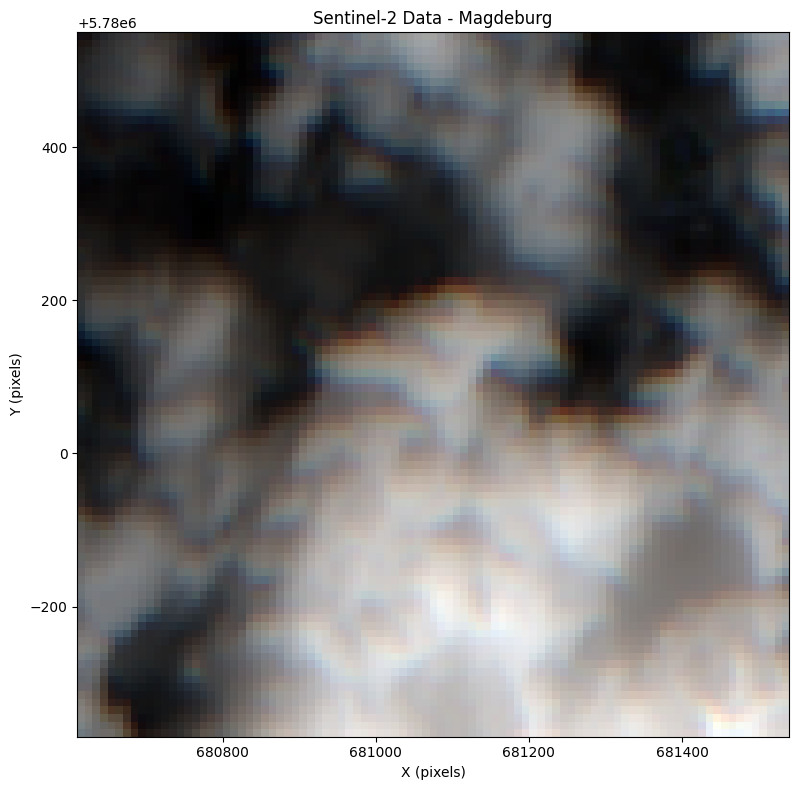

In [4]:
# Verify and inspect the downloaded data
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Recreate the expected output path so this cell can run independently
output_dir = Path("../data/sentinel2")
output_file = output_dir / "magdeburg_sentinel2_20240501.tif"

# If the exact file is not present, fall back to the first GeoTIFF in the folder
if not output_file.exists():
    tif_files = sorted(output_dir.glob("*.tif"))
    if tif_files:
        output_file = tif_files[0]

# Check if download was successful
if output_file.exists():
    print(f"Data file exists: {output_file}")
    print(f"File size: {output_file.stat().st_size / (1024**2):.2f} MB")
    
    # Read and inspect the raster data
    with rasterio.open(output_file) as src:
        print(f"\n  CRS: {src.crs}")
        print(f"  Shape: {src.shape}")
        print(f"  Bounds: {src.bounds}")
        print(f"  Number of bands: {src.count}")
        
        # Read first band (Red band usually)
        band_data = src.read(1)
        print(f"  Data type: {band_data.dtype}")
        print(f"  Min value: {band_data.min()}")
        print(f"  Max value: {band_data.max()}")
        
        # Display a preview of the data
        fig, ax = plt.subplots(figsize=(10, 8))
        show(src, ax=ax)
        plt.title("Sentinel-2 Data - Magdeburg")
        plt.xlabel("X (pixels)")
        plt.ylabel("Y (pixels)")
        plt.tight_layout()
        plt.show()
else:
    print("Download failed or file not found")

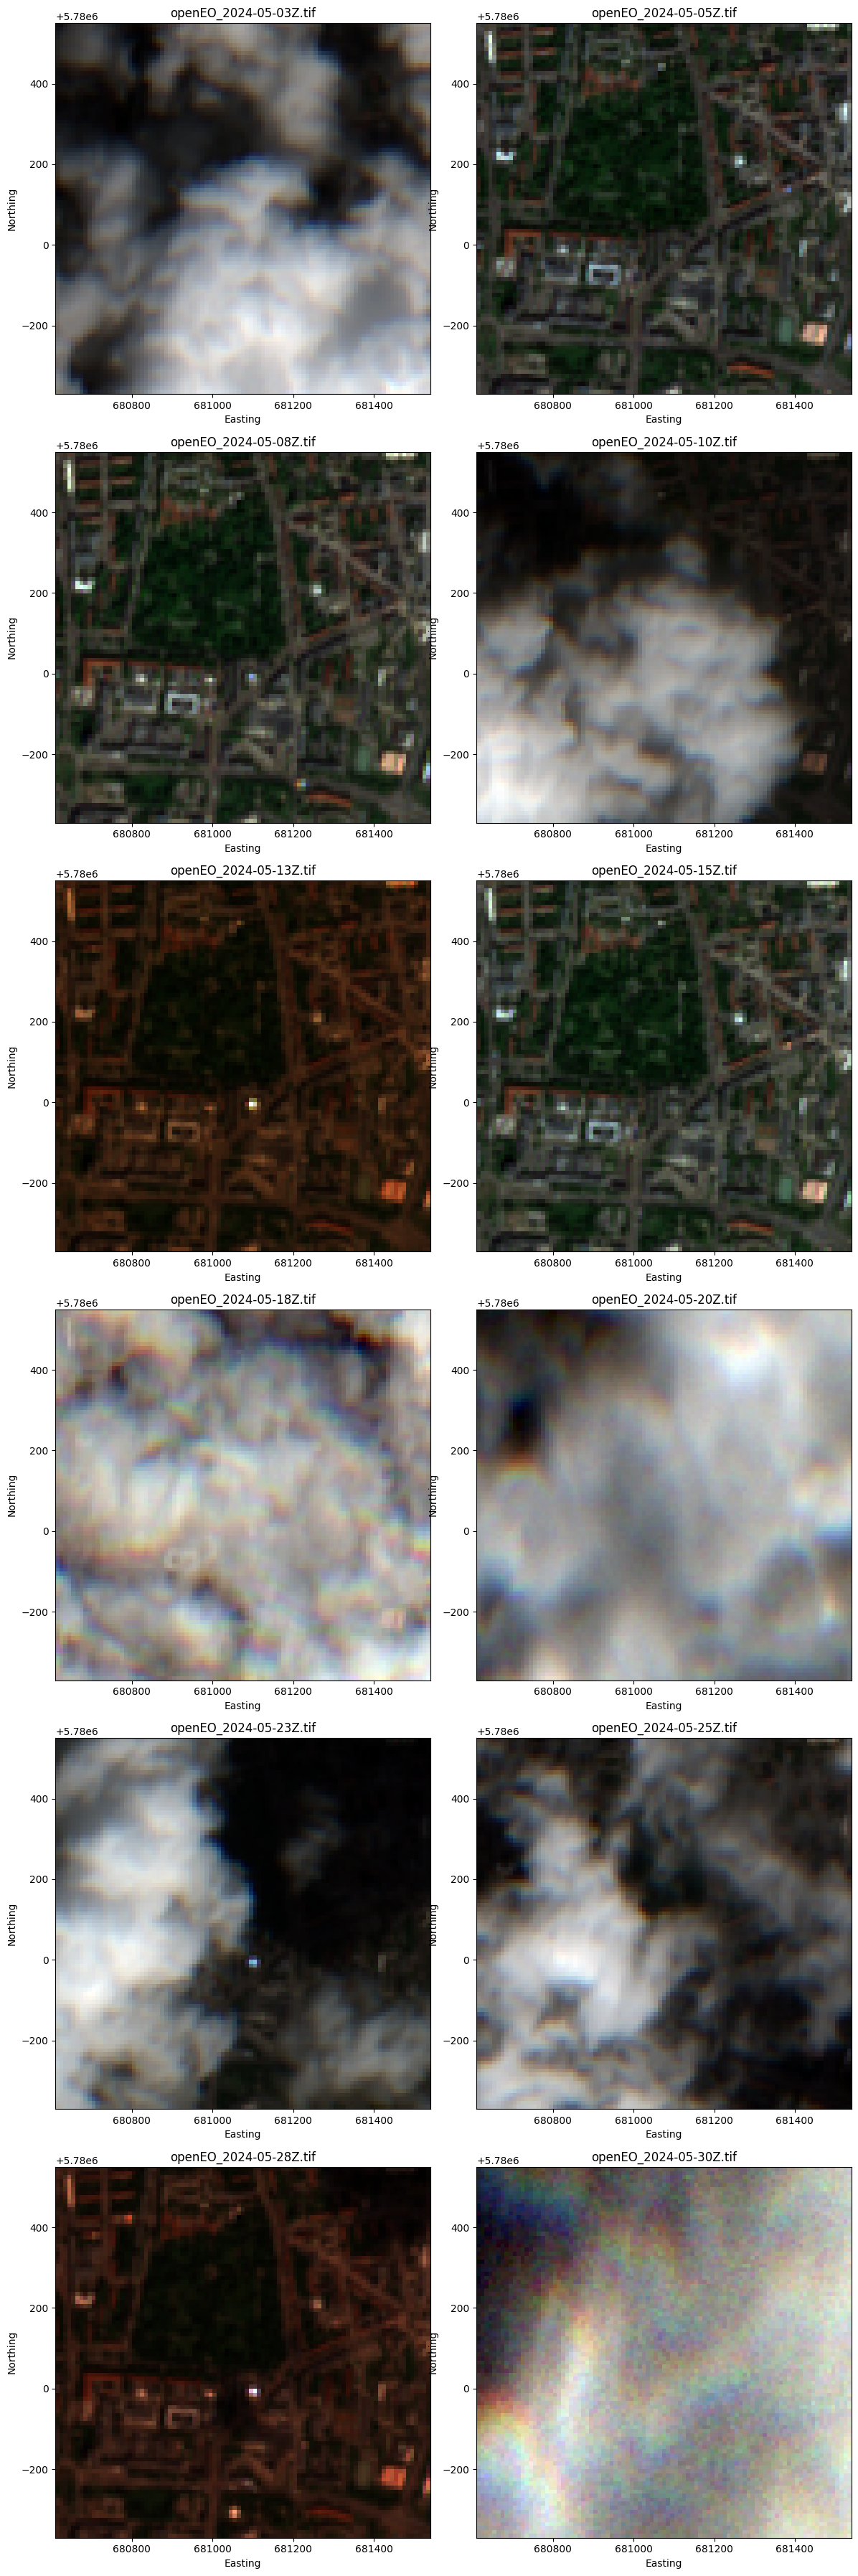

In [10]:
# Visualise all downloaded GeoTIFFs together in a grid
from math import ceil

# Collect every TIFF in the output folder
all_tif_files = sorted(output_dir.glob("*.tif"))

if not all_tif_files:
    print(f"No GeoTIFF files found in {output_dir}")
else:
    n_images = len(all_tif_files)
    ncols = 2 if n_images > 1 else 1
    nrows = ceil(n_images / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, tif_path in zip(axes, all_tif_files):
        with rasterio.open(tif_path) as src:
            # True-color composite for each file: Red, Green, Blue
            rgb = src.read([3, 2, 1])
            show(rgb, ax=ax, transform=src.transform)
            ax.set_title(tif_path.name)
            ax.set_xlabel("Easting")
            ax.set_ylabel("Northing")

    # Hide any unused subplot slots
    for ax in axes[n_images:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Higher-Resolution Orthophotos

Sachsen-Anhalt orthophoto service

https://www.lvermgeo.sachsen-anhalt.de/de/gdp-open-data.html

In [11]:
# Inspect the orthophoto WMS capabilities and list matching layers
import requests
import xml.etree.ElementTree as ET

wms_capabilities_url = "https://www.geodatenportal.sachsen-anhalt.de/wss/service/ST_LVermGeo_DOP_WMS_OpenData/guest?SERVICE=WMS&VERSION=1.3.0&REQUEST=GetCapabilities"
response = requests.get(wms_capabilities_url, timeout=30)
response.raise_for_status()

root = ET.fromstring(response.text)
namespace = {
    "wms": "http://www.opengis.net/wms",
}

layers = []
for layer in root.findall(".//wms:Layer", namespace):
    name_element = layer.find("wms:Name", namespace)
    title_element = layer.find("wms:Title", namespace)
    if name_element is not None and title_element is not None:
        layers.append((name_element.text, title_element.text))

orthophoto_layers = [item for item in layers if item[0] and ("DOP" in item[0] or "Orth" in item[1] or "DOP" in item[1])]

print(f"Found {len(orthophoto_layers)} orthophoto-related layers")
for name, title in orthophoto_layers[:20]:
    print(f"- {name}: {title}")

Found 2 orthophoto-related layers
- lsa_lvermgeo_dop20_2: Digitale Orthophotos
- lsa_lvermgeo_dop100_unbesch: DOP100


In [ ]:
# Download and save orthophotos (DOP20) to ../data/orthophotos
from io import BytesIO
from pathlib import Path
import requests
import matplotlib.pyplot as plt
from PIL import Image
from pyproj import Transformer

output_dir = Path("../data/orthophotos")
output_dir.mkdir(parents=True, exist_ok=True)

wms_getmap_url = "https://www.geodatenportal.sachsen-anhalt.de/wss/service/ST_LVermGeo_DOP_WMS_OpenData/guest"
transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)
requests_timeout = 60

def fetch_and_save(bbox, filename, width_px, height_px):
    min_x, min_y = transformer.transform(bbox["west"], bbox["south"])
    max_x, max_y = transformer.transform(bbox["east"], bbox["north"])
    params = {
        "SERVICE": "WMS",
        "VERSION": "1.3.0",
        "REQUEST": "GetMap",
        "LAYERS": "lsa_lvermgeo_dop20_2",
        "STYLES": "",
        "CRS": "EPSG:25832",
        "BBOX": f"{min_x},{min_y},{max_x},{max_y}",
        "WIDTH": width_px,
        "HEIGHT": height_px,
        "FORMAT": "image/png",
        "TRANSPARENT": "false",
    }
    print(f"Requesting {filename} with BBOX={params['BBOX']}")
    response = requests.get(wms_getmap_url, params=params, timeout=requests_timeout)
    response.raise_for_status()
    out_path = output_dir / filename
    out_path.write_bytes(response.content)
    print(f"Saved {out_path} ({out_path.stat().st_size} bytes)")
    return out_path

# Use the bbox variables defined earlier in the notebook
ovgu_path = fetch_and_save(ovgu_bbox, "dop20_ovgu.png", 1200, 1200)
magdeburg_path = fetch_and_save(magdeburg_bbox, "dop20_magdeburg.png", 1600, 1200)

# Plot each image separately
for img_path in [ovgu_path, magdeburg_path]:
    image = Image.open(img_path)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)
    ax.set_title(img_path.name)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

print("All images saved to:", output_dir)

Requesting dop20_ovgu.png with BBOX=680650.1286411083,5779636.164493273,681504.8424704387,5780544.191040694
Saved ../data/orthophotos/dop20_ovgu.png (3413790 bytes)
Requesting dop20_magdeburg.png with BBOX=671613.2237577542,5763989.366599672,704548.5540451109,5798644.6756523205
